<a href="https://colab.research.google.com/github/sadichyaa/Assesment1/blob/main/2436299_SadikshyaNepal_final_assesment_Part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

sadikshyanepal_fruits_path = kagglehub.dataset_download('sadikshyanepal/fruits')

print('Data source import complete.')


# 6CS012 — PART II: VISION TASK
# Fruit Classification using CNN and Transfer Learning (ResNet50)

**Dataset:** Fruits Dataset (15 classes)  
**Framework:** Keras / TensorFlow  
**Hardware:** GPU (Google Colab / Kaggle)

---
## SECTION 1 — Import Libraries

In [ ]:
# SECTION 1 - IMPORT LIBRARIES
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Flatten,
    Dropout, BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.applications import ResNet50

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


---
## SECTION 2 — Dataset Paths

In [ ]:
# SECTION 2 - DATASET PATHS
# Adjust paths to match your environment (Kaggle / Colab / local)

train_dir = "/kaggle/input/datasets/sadikshyanepal/fruits/fruits_dataset/Training"
test_dir  = "/kaggle/input/datasets/sadikshyanepal/fruits/fruits_dataset/Test"

print("Train dir:", train_dir)
print("Test  dir:", test_dir)

Train dir: /kaggle/input/datasets/sadikshyanepal/fruits/fruits_dataset/Training
Test  dir: /kaggle/input/datasets/sadikshyanepal/fruits/fruits_dataset/Test


---
## SECTION 3 — Data Understanding & Analysis

### 3.1 Dataset Description

The **Fruits Dataset** contains colour images of 15 different fruit categories photographed against clean backgrounds. Each image is labelled with its corresponding fruit class. This is a multi-class image-classification task.

### 3.2 Count images and class distribution

In [ ]:
# SECTION 3 - DATA UNDERSTANDING
classes = sorted(os.listdir(train_dir))
print(f"Total Classes : {len(classes)}")
print("Classes       :", classes)

# Per-class image counts
class_counts = []
for cls in classes:
    path = os.path.join(train_dir, cls)
    count = len(os.listdir(path))
    class_counts.append(count)

total_images = sum(class_counts)
print(f"\nTotal Training Images: {total_images}")

# Summary table
df_dist = pd.DataFrame({"Class": classes, "Count": class_counts})
print("\nClass Distribution:")
print(df_dist.to_string(index=False))

Total Classes : 15
Classes       : ['Apricot', 'Avocado', 'Banana', 'Blueberry', 'Guava', 'Kiwi', 'Lychee', 'Mango', 'Orange', 'Peach', 'Pineapple', 'Pomegranate', 'Raspberry', 'Strawberry', 'Watermelon']

Total Training Images: 7217

Class Distribution:
      Class  Count
    Apricot    492
    Avocado    427
     Banana    490
  Blueberry    462
      Guava    490
       Kiwi    466
     Lychee    490
      Mango    490
     Orange    479
      Peach    492
  Pineapple    490
Pomegranate    492
  Raspberry    490
 Strawberry    492
 Watermelon    475


### 3.3 Class Distribution Bar Chart

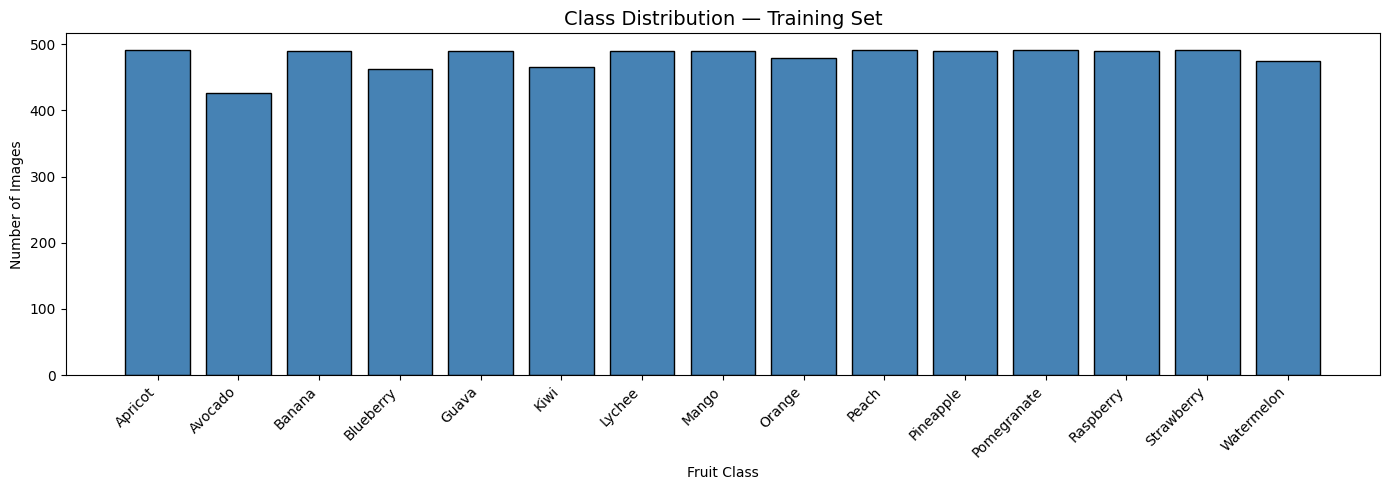

Min images per class : 427 (Avocado)
Max images per class : 492 (Apricot)
Mean images per class: 481.1


In [ ]:
# SECTION 4 - CLASS DISTRIBUTION VISUALIZATION
plt.figure(figsize=(14, 5))
plt.bar(classes, class_counts, color='steelblue', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.title("Class Distribution — Training Set", fontsize=14)
plt.xlabel("Fruit Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

print(f"Min images per class : {min(class_counts)} ({classes[np.argmin(class_counts)]})")
print(f"Max images per class : {max(class_counts)} ({classes[np.argmax(class_counts)]})")
print(f"Mean images per class: {np.mean(class_counts):.1f}")

### 3.4 Sample Images from Each Class

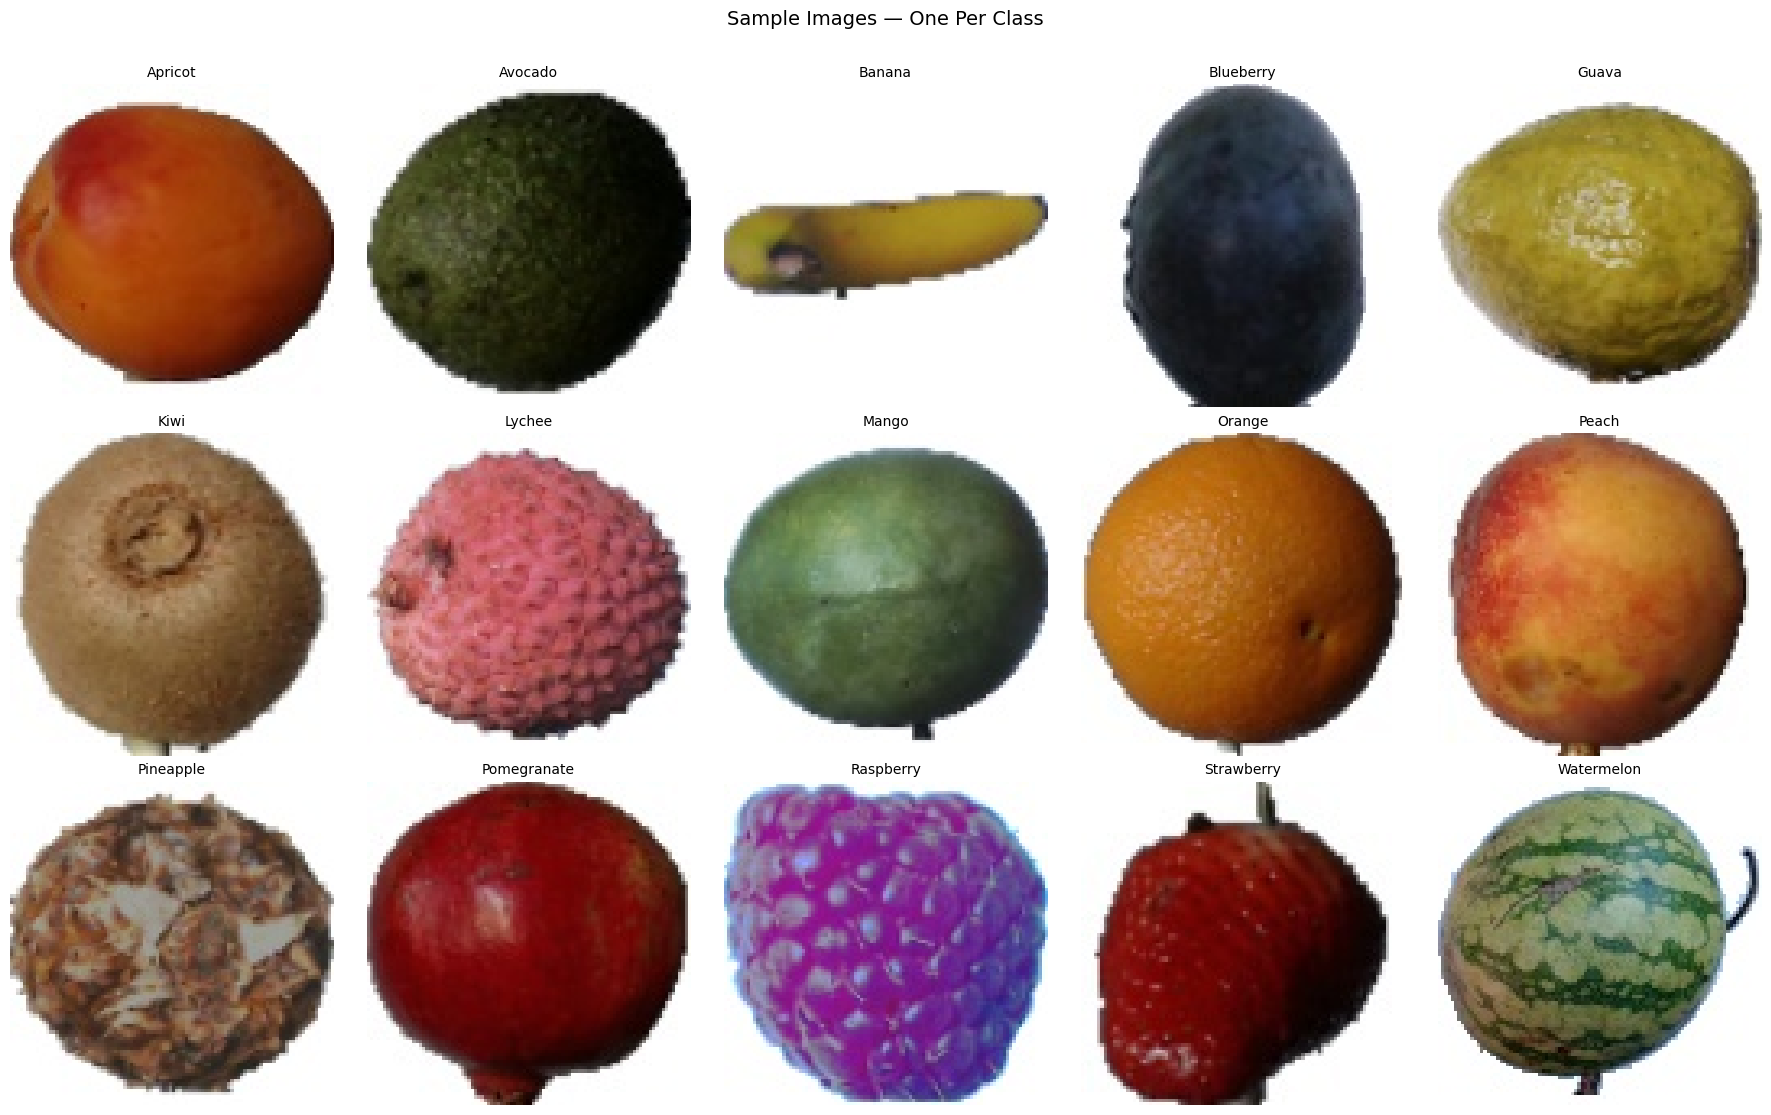

In [ ]:
# SECTION 5 - VISUALIZE SAMPLE IMAGES
fig, axes = plt.subplots(3, 5, figsize=(18, 11))
axes = axes.flatten()

for idx, cls in enumerate(classes):
    cls_path = os.path.join(train_dir, cls)
    img_file = os.listdir(cls_path)[0]          # first image in folder
    img = load_img(os.path.join(cls_path, img_file), target_size=(100, 100))
    axes[idx].imshow(img)
    axes[idx].set_title(cls, fontsize=10)
    axes[idx].axis('off')

plt.suptitle("Sample Images — One Per Class", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## SECTION 4 — Preprocessing & Data Generators

**Preprocessing choices:**
- Resize all images to **64 × 64** pixels (suitable for baseline CNN; kept consistent across Part A).
- Pixel values **rescaled to [0, 1]** by dividing by 255.
- Training set uses **data augmentation** (horizontal flip, small rotation, zoom) to improve generalisation.
- Validation/test sets use **only rescaling** (no augmentation) to give a fair evaluation.
- **80 / 20 split** of the training directory into train / validation (via `validation_split=0.2`).

> **Why these choices?**  64 × 64 keeps training fast on free GPU tiers. Augmentation adds diversity without extra data.

In [ ]:
# SECTION 6 - DATA GENERATORS FOR PART A  (64x64)
IMG_SIZE_A  = (64, 64)
BATCH_SIZE  = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE_A,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE_A,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)

test_gen = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE_A,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = len(classes)
print(f"Training   batches : {len(train_gen)}")
print(f"Validation batches : {len(val_gen)}")
print(f"Test       batches : {len(test_gen)}")
print(f"Number of classes  : {NUM_CLASSES}")

Found 5777 images belonging to 15 classes.
Found 1440 images belonging to 15 classes.
Found 2422 images belonging to 15 classes.
Training   batches : 181
Validation batches : 45
Test       batches : 76
Number of classes  : 15


### 4.1 Augmented Image Visualisation

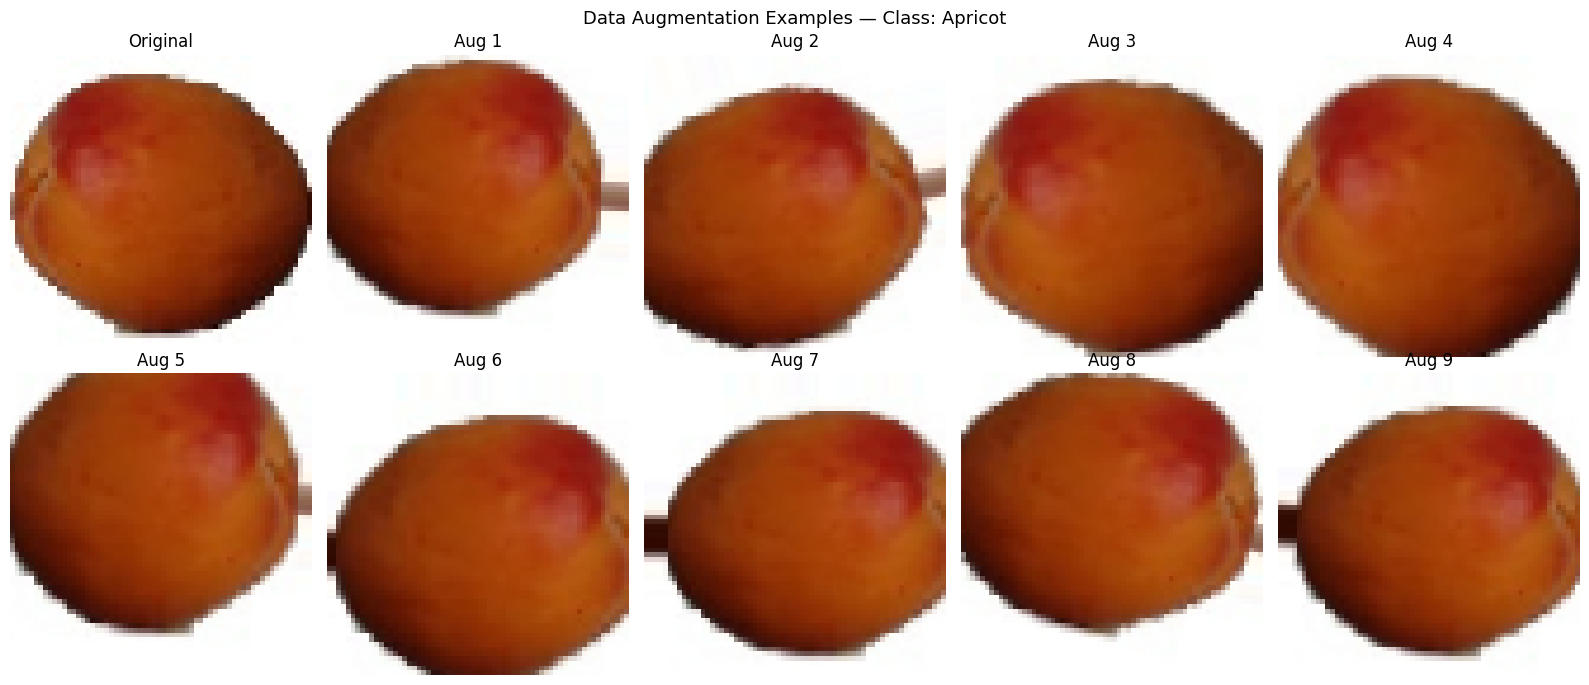

In [ ]:
# SECTION 7 - VISUALIZE AUGMENTED IMAGES
# Take one image and show 10 augmented versions
sample_cls = classes[0]
sample_path = os.path.join(train_dir, sample_cls)
sample_file = os.listdir(sample_path)[0]
orig_img = load_img(os.path.join(sample_path, sample_file), target_size=IMG_SIZE_A)
orig_arr = img_to_array(orig_img)
orig_arr = orig_arr.reshape((1,) + orig_arr.shape)

aug_gen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()
axes[0].imshow(orig_img)
axes[0].set_title("Original")
axes[0].axis('off')

batch = aug_gen.flow(orig_arr, batch_size=1)
for i in range(1, 10):
    aug_img = next(batch)[0].astype('uint8')
    axes[i].imshow(aug_img)
    axes[i].set_title(f"Aug {i}")
    axes[i].axis('off')

plt.suptitle(f"Data Augmentation Examples — Class: {sample_cls}", fontsize=13)
plt.tight_layout()
plt.show()

---
## SECTION 5 — PART A: CNN from Scratch

### 5.1 Baseline CNN Model

**Architecture:**
- 3 × (Conv2D → MaxPooling2D)
- 3 × Dense (Fully Connected)
- Output: Softmax with `NUM_CLASSES` units

**Design choices:** 32 / 64 / 128 filters with 3×3 kernels, ReLU activations, 2×2 max-pooling.

In [ ]:
# SECTION 8 - BASELINE CNN MODEL
def build_baseline_model(num_classes, input_shape=(64, 64, 3)):
    model = Sequential([
        # --- Convolutional Block 1 ---
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        MaxPooling2D((2, 2)),

        # --- Convolutional Block 2 ---
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),

        # --- Convolutional Block 3 ---
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),

        # --- Fully Connected Layers ---
        Flatten(),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(64,  activation='relu'),

        # --- Output Layer ---
        Dense(num_classes, activation='softmax')
    ], name="Baseline_CNN")
    return model

baseline_model = build_baseline_model(NUM_CLASSES)
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,232,783 (8.52 MB)

 Trainable params: 2,232,783 (8.52 MB)

 Non-trainable params: 0 (0.00 B)

### 5.2 Train Baseline Model

In [ ]:
# SECTION 9 - COMPILE & TRAIN BASELINE MODEL
baseline_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

start_time = time.time()
history_baseline = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=[early_stop],
    verbose=1
)
baseline_train_time = time.time() - start_time
print(f"\nBaseline training time: {baseline_train_time:.1f} seconds")

Epoch 1/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 45s 234ms/step - accuracy: 0.8428 - loss: 0.5394 - val_accuracy: 0.9458 - val_loss: 0.1657
Epoch 2/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 17s 92ms/step - accuracy: 0.9828 - loss: 0.0516 - val_accuracy: 0.9743 - val_loss: 0.0786
Epoch 3/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 17s 92ms/step - accuracy: 0.9756 - loss: 0.0714 - val_accuracy: 0.9792 - val_loss: 0.0623
Epoch 4/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 17s 91ms/step - accuracy: 0.9838 - loss: 0.0421 - val_accuracy: 0.9972 - val_loss: 0.0095
Epoch 5/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 17s 92ms/step - accuracy: 0.9978 - loss: 0.0076 - val_accuracy: 0.9972 - val_loss: 0.0084
Epoch 6/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 17s 92ms/step - accuracy: 0.9983 - loss: 0.0064 - val_accuracy: 0.9986 - val_loss: 0.0062
Epoch 7/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 17s 92ms/step - accuracy: 0.9634 - loss: 0.1275 - val_accuracy: 0.9604 - val_loss: 0.2577
Epoch 8/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 16s 90ms/step - accuracy: 0.9801 - loss: 0.0782 -

### 5.3 Training & Validation Loss / Accuracy Curves — Baseline

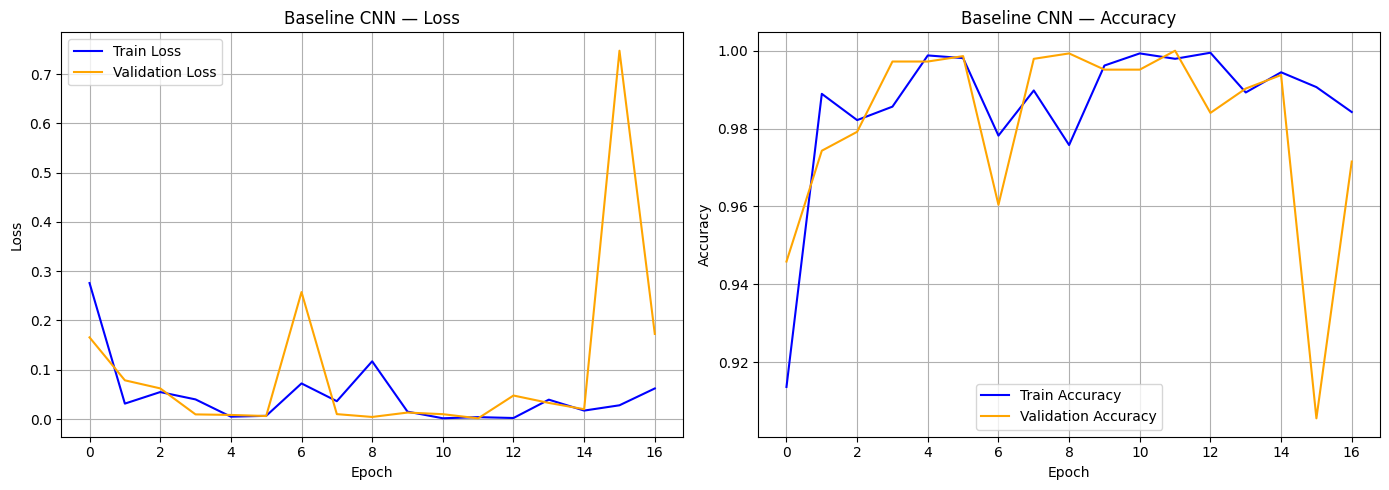

In [ ]:
# SECTION 10 - PLOT BASELINE TRAINING CURVES
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_baseline.history['loss'],     label='Train Loss',      color='blue')
axes[0].plot(history_baseline.history['val_loss'], label='Validation Loss', color='orange')
axes[0].set_title('Baseline CNN — Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history_baseline.history['accuracy'],     label='Train Accuracy',      color='blue')
axes[1].plot(history_baseline.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[1].set_title('Baseline CNN — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### 5.4 Evaluate Baseline Model

Baseline Test Accuracy : 100.00%
Baseline Test Loss     : 0.0001

Classification Report — Baseline CNN:
              precision    recall  f1-score   support

     Apricot       1.00      1.00      1.00       164
     Avocado       1.00      1.00      1.00       143
      Banana       1.00      1.00      1.00       166
   Blueberry       1.00      1.00      1.00       154
       Guava       1.00      1.00      1.00       166
        Kiwi       1.00      1.00      1.00       156
      Lychee       1.00      1.00      1.00       166
       Mango       1.00      1.00      1.00       166
      Orange       1.00      1.00      1.00       160
       Peach       1.00      1.00      1.00       164
   Pineapple       1.00      1.00      1.00       166
 Pomegranate       1.00      1.00      1.00       164
   Raspberry       1.00      1.00      1.00       166
  Strawberry       1.00      1.00      1.00       164
  Watermelon       1.00      1.00      1.00       157

    accuracy                  

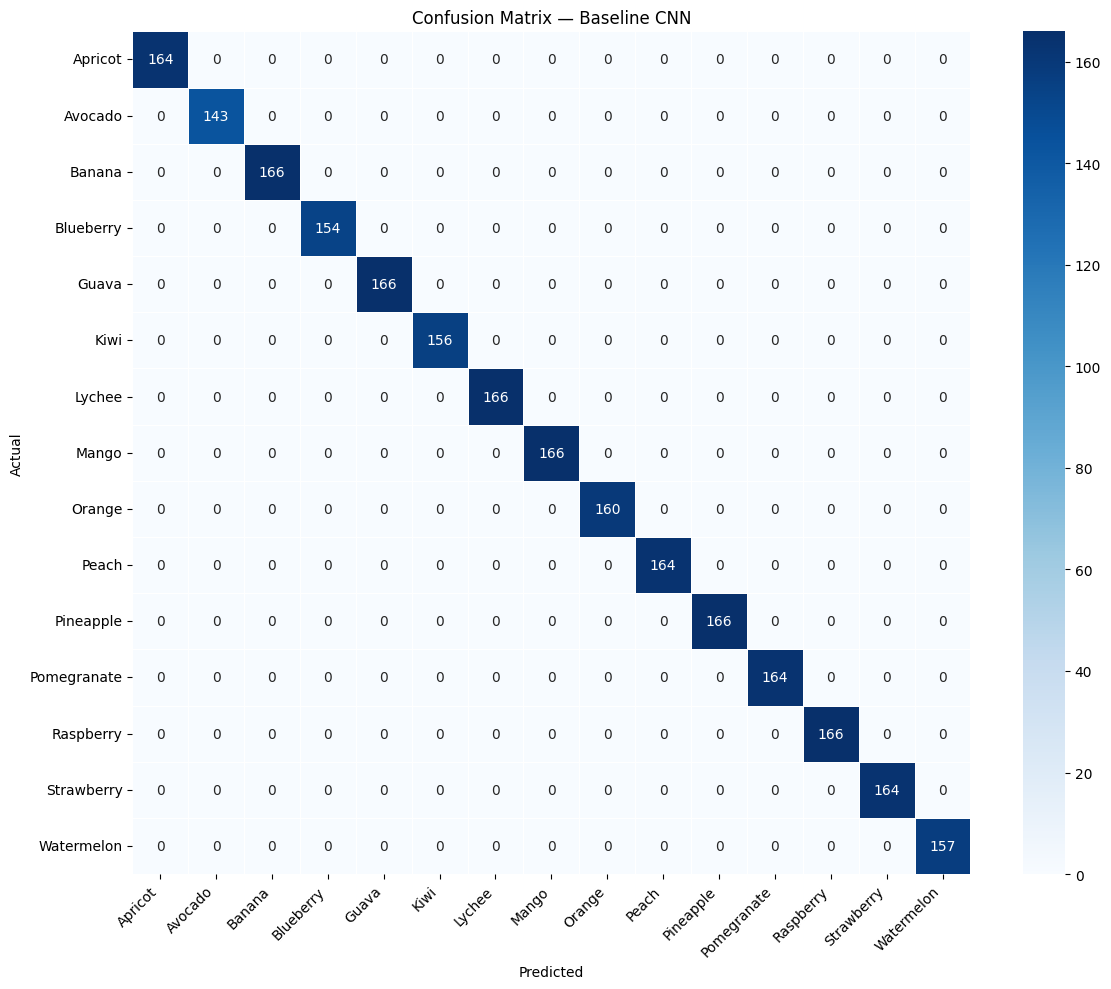

In [ ]:
# SECTION 11 - EVALUATE BASELINE MODEL
test_gen.reset()
baseline_loss, baseline_accuracy = baseline_model.evaluate(test_gen, verbose=0)
print(f"Baseline Test Accuracy : {baseline_accuracy*100:.2f}%")
print(f"Baseline Test Loss     : {baseline_loss:.4f}")

# Predictions for detailed metrics
test_gen.reset()
y_pred_baseline = baseline_model.predict(test_gen, verbose=0)
y_pred_classes  = np.argmax(y_pred_baseline, axis=1)
y_true          = test_gen.classes

print("\nClassification Report — Baseline CNN:")
print(classification_report(y_true, y_pred_classes, target_names=classes))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes,
            cmap='Blues', linewidths=0.5)
plt.title('Confusion Matrix — Baseline CNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5.5 Inference on Sample Test Images — Baseline

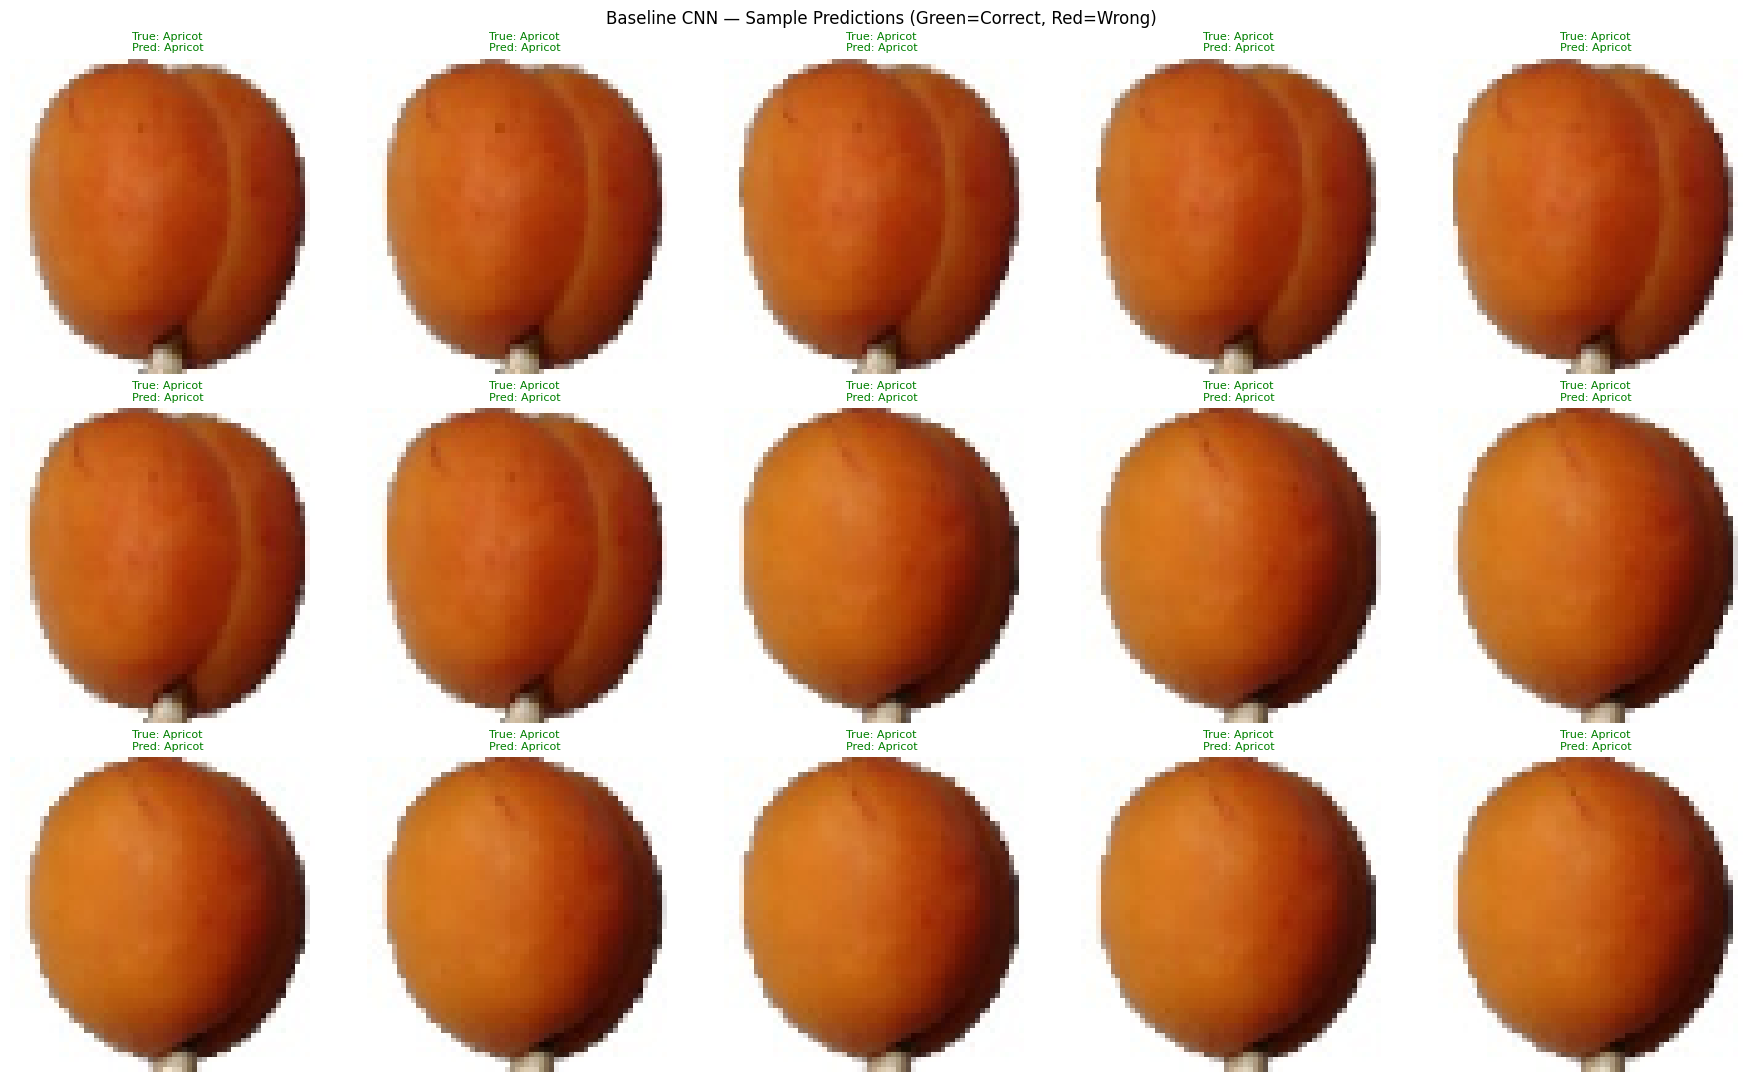

In [ ]:
# SECTION 12 - INFERENCE ON SAMPLE IMAGES (BASELINE)
test_gen.reset()
batch_imgs, batch_labels = next(test_gen)

fig, axes = plt.subplots(3, 5, figsize=(18, 11))
axes = axes.flatten()

for i in range(15):
    axes[i].imshow(batch_imgs[i])
    true_cls  = classes[np.argmax(batch_labels[i])]
    pred_cls  = classes[np.argmax(baseline_model.predict(batch_imgs[i:i+1], verbose=0))]
    color     = 'green' if true_cls == pred_cls else 'red'
    axes[i].set_title(f"True: {true_cls}\nPred: {pred_cls}", color=color, fontsize=8)
    axes[i].axis('off')

plt.suptitle("Baseline CNN — Sample Predictions (Green=Correct, Red=Wrong)", fontsize=12)
plt.tight_layout()
plt.show()

---
## SECTION 6 — Deeper CNN with Regularisation

**Architecture:** Doubles the layers (6 Conv blocks instead of 3) and adds:
- **BatchNormalization** after each Conv layer to stabilise training and speed convergence.
- **Dropout(0.4)** before dense layers to reduce overfitting.

> At least double the layers compared to the baseline as required.

In [ ]:
# SECTION 13 - DEEP CNN WITH BATCH NORM + DROPOUT
def build_deep_model(num_classes, input_shape=(64, 64, 3)):
    model = Sequential([
        # --- Block 1 ---
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # --- Block 2 ---
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # --- Block 3 ---
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # --- Fully Connected ---
        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),

        # --- Output ---
        Dense(num_classes, activation='softmax')
    ], name="Deep_CNN")
    return model

deep_model = build_deep_model(NUM_CLASSES)
deep_model.summary()

Model: "Deep_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,651,823 (17.75 MB)

 Trainable params: 4,649,903 (17.74 MB)

 Non-trainable params: 1,920 (7.50 KB)

### 6.1 Train Deep Model

In [ ]:
# SECTION 14 - COMPILE & TRAIN DEEP MODEL
deep_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

train_gen.reset(); val_gen.reset()
start_time = time.time()
history_deep = deep_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)
deep_train_time = time.time() - start_time
print(f"\nDeep CNN training time: {deep_train_time:.1f} seconds")

Epoch 1/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 36s 138ms/step - accuracy: 0.9755 - loss: 0.0941 - val_accuracy: 0.9979 - val_loss: 0.0044
Epoch 2/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 18s 100ms/step - accuracy: 0.9911 - loss: 0.0341 - val_accuracy: 0.9187 - val_loss: 0.3743
Epoch 3/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 17s 96ms/step - accuracy: 0.9809 - loss: 0.0780 - val_accuracy: 0.9931 - val_loss: 0.0230
Epoch 4/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 17s 94ms/step - accuracy: 0.9888 - loss: 0.0451 - val_accuracy: 0.9993 - val_loss: 0.0023
Epoch 5/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 17s 92ms/step - accuracy: 0.9930 - loss: 0.0236 - val_accuracy: 0.9958 - val_loss: 0.0099
Epoch 6/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 17s 95ms/step - accuracy: 0.9952 - loss: 0.0195 - val_accuracy: 0.8618 - val_loss: 0.9720
Epoch 7/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 17s 91ms/step - accuracy: 0.9858 - loss: 0.0455 - val_accuracy: 0.9639 - val_loss: 0.1067
Epoch 8/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 17s 92ms/step - accuracy: 0.9961 - loss: 0.0143 

### 6.2 Training Curves — Deep Model

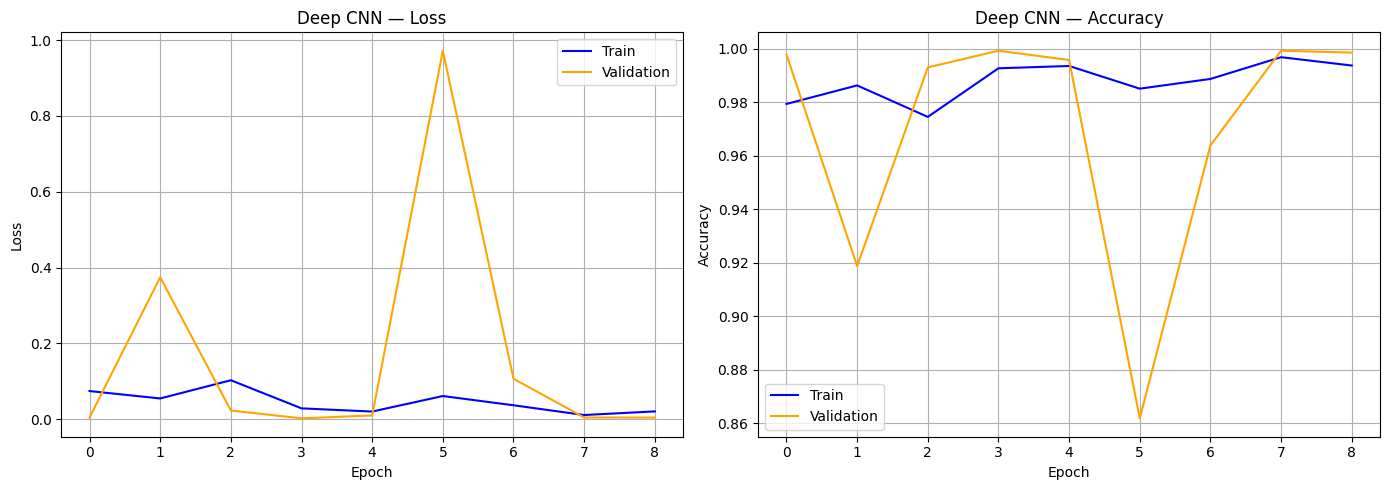

In [ ]:
# SECTION 15 - PLOT DEEP MODEL TRAINING CURVES
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_deep.history['loss'],     label='Train',      color='blue')
axes[0].plot(history_deep.history['val_loss'], label='Validation', color='orange')
axes[0].set_title('Deep CNN — Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history_deep.history['accuracy'],     label='Train',      color='blue')
axes[1].plot(history_deep.history['val_accuracy'], label='Validation', color='orange')
axes[1].set_title('Deep CNN — Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

### 6.3 Evaluate Deep Model

Deep CNN Test Accuracy : 97.69%
Deep CNN Test Loss     : 0.0547

Classification Report — Deep CNN:
              precision    recall  f1-score   support

     Apricot       1.00      0.66      0.79       164
     Avocado       1.00      1.00      1.00       143
      Banana       1.00      1.00      1.00       166
   Blueberry       1.00      1.00      1.00       154
       Guava       1.00      1.00      1.00       166
        Kiwi       1.00      1.00      1.00       156
      Lychee       1.00      1.00      1.00       166
       Mango       1.00      1.00      1.00       166
      Orange       0.74      1.00      0.85       160
       Peach       1.00      1.00      1.00       164
   Pineapple       1.00      1.00      1.00       166
 Pomegranate       1.00      1.00      1.00       164
   Raspberry       1.00      1.00      1.00       166
  Strawberry       1.00      1.00      1.00       164
  Watermelon       1.00      1.00      1.00       157

    accuracy                       

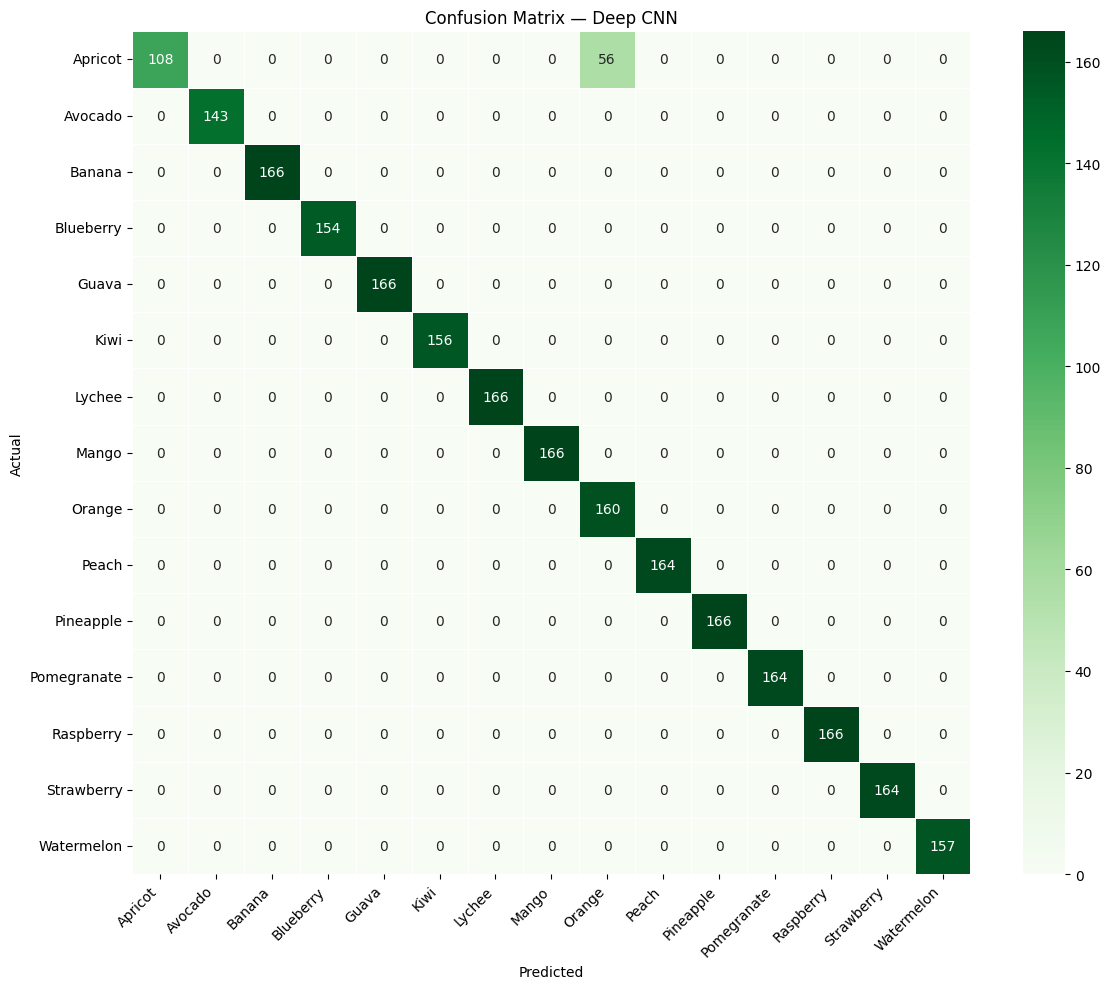

In [ ]:
# SECTION 16 - EVALUATE DEEP MODEL
test_gen.reset()
deep_loss, deep_accuracy = deep_model.evaluate(test_gen, verbose=0)
print(f"Deep CNN Test Accuracy : {deep_accuracy*100:.2f}%")
print(f"Deep CNN Test Loss     : {deep_loss:.4f}")

test_gen.reset()
y_pred_deep   = deep_model.predict(test_gen, verbose=0)
y_pred_deep_c = np.argmax(y_pred_deep, axis=1)
y_true        = test_gen.classes

print("\nClassification Report — Deep CNN:")
print(classification_report(y_true, y_pred_deep_c, target_names=classes))

cm_deep = confusion_matrix(y_true, y_pred_deep_c)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_deep, annot=True, fmt='d', xticklabels=classes, yticklabels=classes,
            cmap='Greens', linewidths=0.5)
plt.title('Confusion Matrix — Deep CNN')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## SECTION 7 — Experimentation and Comparative Analysis

### 7.1 Baseline vs Deep Model — Performance Comparison

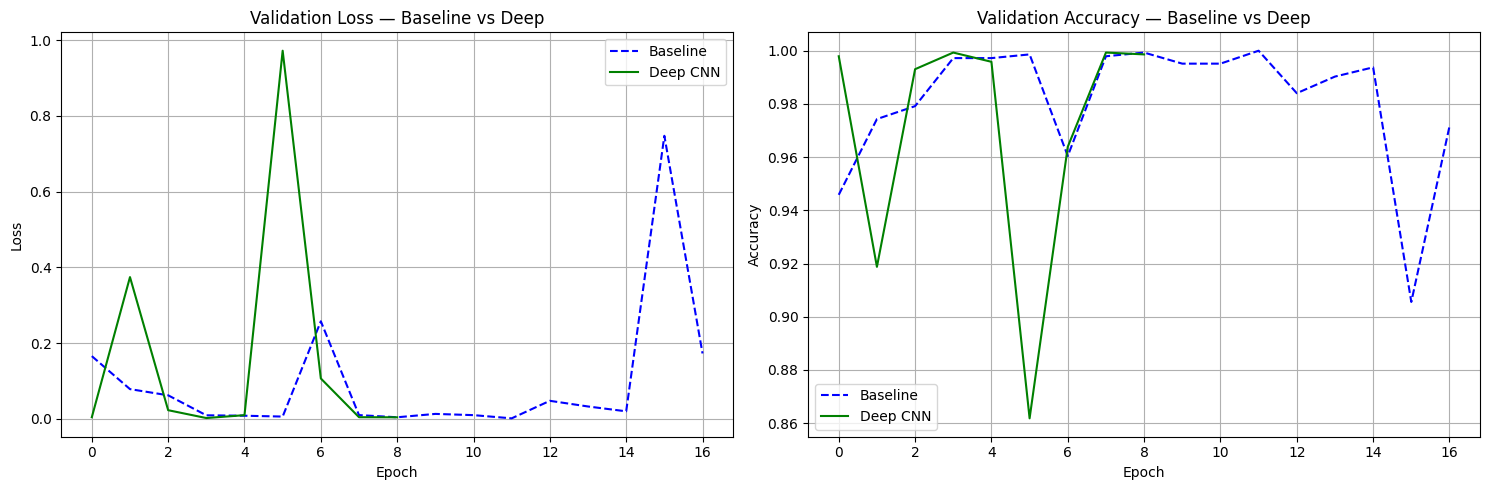


--- Performance Summary ---
Baseline Test Accuracy : 100.00%  | Training Time: 311.1s
Deep CNN Test Accuracy : 97.69%  | Training Time: 172.1s


In [ ]:
# SECTION 17 - BASELINE VS DEEP: SIDE-BY-SIDE LOSS CURVES
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Validation Loss
axes[0].plot(history_baseline.history['val_loss'], label='Baseline', color='blue',   linestyle='--')
axes[0].plot(history_deep.history['val_loss'],     label='Deep CNN', color='green',  linestyle='-')
axes[0].set_title('Validation Loss — Baseline vs Deep')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

# Validation Accuracy
axes[1].plot(history_baseline.history['val_accuracy'], label='Baseline', color='blue',  linestyle='--')
axes[1].plot(history_deep.history['val_accuracy'],     label='Deep CNN', color='green', linestyle='-')
axes[1].set_title('Validation Accuracy — Baseline vs Deep')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

print("\n--- Performance Summary ---")
print(f"Baseline Test Accuracy : {baseline_accuracy*100:.2f}%  | Training Time: {baseline_train_time:.1f}s")
print(f"Deep CNN Test Accuracy : {deep_accuracy*100:.2f}%  | Training Time: {deep_train_time:.1f}s")

### 7.2 Computational Efficiency — Training Time Comparison

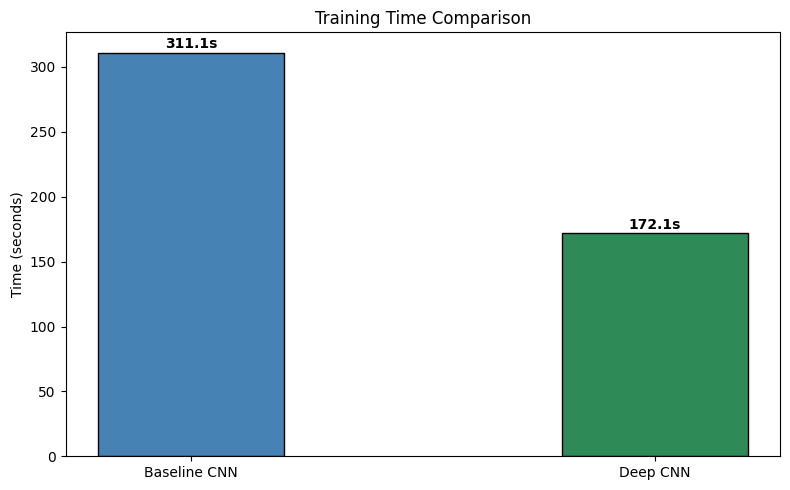


Observation:
The Deep CNN has more parameters and more layers, so it typically takes
longer to train per epoch, but may converge faster due to BatchNormalization.


In [ ]:
# SECTION 18 - TRAINING TIME COMPARISON
models_list = ['Baseline CNN', 'Deep CNN']
times_list  = [baseline_train_time, deep_train_time]

plt.figure(figsize=(8, 5))
bars = plt.bar(models_list, times_list, color=['steelblue', 'seagreen'], edgecolor='black', width=0.4)
plt.title('Training Time Comparison')
plt.ylabel('Time (seconds)')
for bar, t in zip(bars, times_list):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{t:.1f}s',
             ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nObservation:")
print("The Deep CNN has more parameters and more layers, so it typically takes")
print("longer to train per epoch, but may converge faster due to BatchNormalization.")

### 7.3 Optimizer Analysis — SGD vs Adam (Deep CNN)

We retrain the deep architecture twice — once with **SGD** (momentum 0.9) and once with **Adam** — to compare convergence speed and final accuracy.

In [ ]:
# SECTION 19 - SGD OPTIMIZER — DEEP CNN
deep_sgd = build_deep_model(NUM_CLASSES)
deep_sgd.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

train_gen.reset(); val_gen.reset()
start = time.time()
history_sgd = deep_sgd.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)
sgd_time = time.time() - start
test_gen.reset()
sgd_loss, sgd_acc = deep_sgd.evaluate(test_gen, verbose=0)
print(f"SGD  — Test Accuracy: {sgd_acc*100:.2f}% | Time: {sgd_time:.1f}s")

Epoch 1/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 33s 136ms/step - accuracy: 0.5812 - loss: 1.2219 - val_accuracy: 0.2375 - val_loss: 7.6551
Epoch 2/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 17s 92ms/step - accuracy: 0.9284 - loss: 0.2068 - val_accuracy: 0.9701 - val_loss: 0.0849
Epoch 3/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 17s 92ms/step - accuracy: 0.9477 - loss: 0.1452 - val_accuracy: 0.9868 - val_loss: 0.0362
Epoch 4/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 17s 93ms/step - accuracy: 0.9635 - loss: 0.0986 - val_accuracy: 0.9972 - val_loss: 0.0118
Epoch 5/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 17s 93ms/step - accuracy: 0.9849 - loss: 0.0495 - val_accuracy: 0.9750 - val_loss: 0.0671
Epoch 6/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 17s 92ms/step - accuracy: 0.9814 - loss: 0.0651 - val_accuracy: 0.9965 - val_loss: 0.0163
Epoch 7/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 17s 92ms/step - accuracy: 0.9868 - loss: 0.0311 - val_accuracy: 0.8972 - val_loss: 0.2934
Epoch 8/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 17s 95ms/step - accuracy: 0.9892 - loss: 0.0332 -

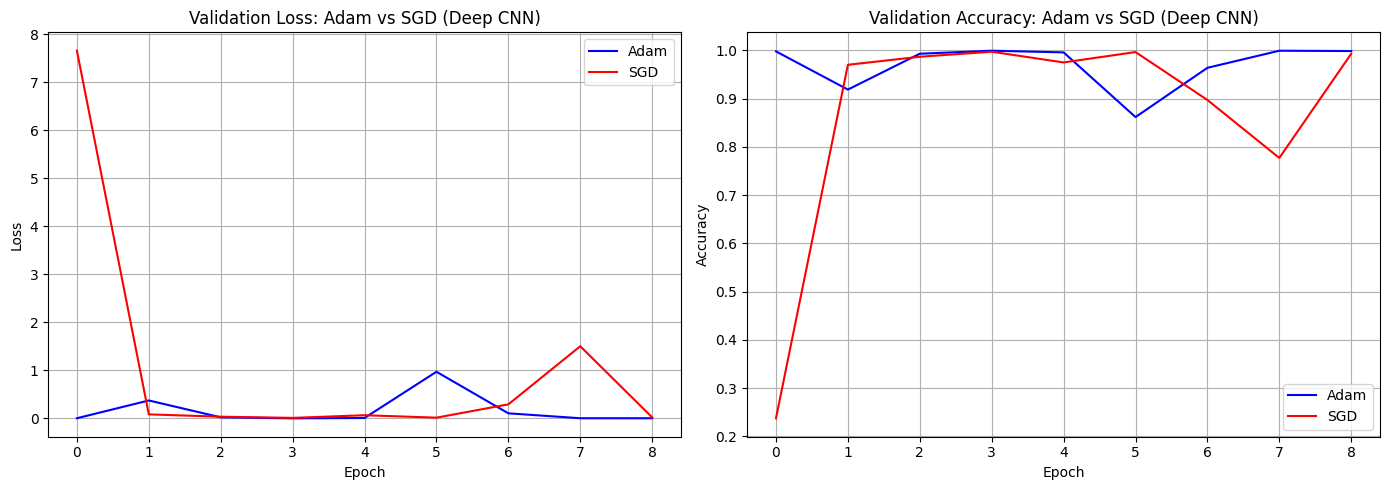


Adam Test Accuracy : 97.69%
SGD  Test Accuracy : 100.00%

Analysis: Adam generally converges faster due to adaptive learning rates.
SGD with momentum can reach similar accuracy but may need more epochs.


In [ ]:
# SECTION 20 - ADAM vs SGD COMPARISON PLOT
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_deep.history['val_loss'], label='Adam', color='blue')
axes[0].plot(history_sgd.history['val_loss'],  label='SGD',  color='red')
axes[0].set_title('Validation Loss: Adam vs SGD (Deep CNN)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history_deep.history['val_accuracy'], label='Adam', color='blue')
axes[1].plot(history_sgd.history['val_accuracy'],  label='SGD',  color='red')
axes[1].set_title('Validation Accuracy: Adam vs SGD (Deep CNN)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"\nAdam Test Accuracy : {deep_accuracy*100:.2f}%")
print(f"SGD  Test Accuracy : {sgd_acc*100:.2f}%")
print("\nAnalysis: Adam generally converges faster due to adaptive learning rates.")
print("SGD with momentum can reach similar accuracy but may need more epochs.")

### 7.4 Ablation Study — Effect of Removing Dropout

We build the same deep architecture **without Dropout** to measure its impact.

In [ ]:
# SECTION 21 - ABLATION: DEEP CNN WITHOUT DROPOUT
def build_deep_no_dropout(num_classes, input_shape=(64, 64, 3)):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        # NO DROPOUT HERE
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax')
    ], name="Deep_CNN_No_Dropout")
    return model

ablation_model = build_deep_no_dropout(NUM_CLASSES)
ablation_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

train_gen.reset(); val_gen.reset()
history_ablation = ablation_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)
test_gen.reset()
abl_loss, abl_acc = ablation_model.evaluate(test_gen, verbose=0)
print(f"No-Dropout Test Accuracy: {abl_acc*100:.2f}%")

Epoch 1/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 35s 150ms/step - accuracy: 0.8427 - loss: 0.5239 - val_accuracy: 0.2424 - val_loss: 6.6874
Epoch 2/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 17s 96ms/step - accuracy: 0.9751 - loss: 0.0937 - val_accuracy: 0.2972 - val_loss: 4.8043
Epoch 3/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 17s 93ms/step - accuracy: 0.9637 - loss: 0.1354 - val_accuracy: 0.8271 - val_loss: 0.8998
Epoch 4/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 17s 92ms/step - accuracy: 0.9968 - loss: 0.0106 - val_accuracy: 0.9868 - val_loss: 0.0445
Epoch 5/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 17s 92ms/step - accuracy: 0.9759 - loss: 0.0855 - val_accuracy: 0.9771 - val_loss: 0.0643
Epoch 6/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 17s 91ms/step - accuracy: 0.9913 - loss: 0.0291 - val_accuracy: 0.9958 - val_loss: 0.0111
Epoch 7/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 17s 92ms/step - accuracy: 0.9939 - loss: 0.0184 - val_accuracy: 0.9340 - val_loss: 0.2050
Epoch 8/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 16s 90ms/step - accuracy: 0.9977 - loss: 0.0094 -

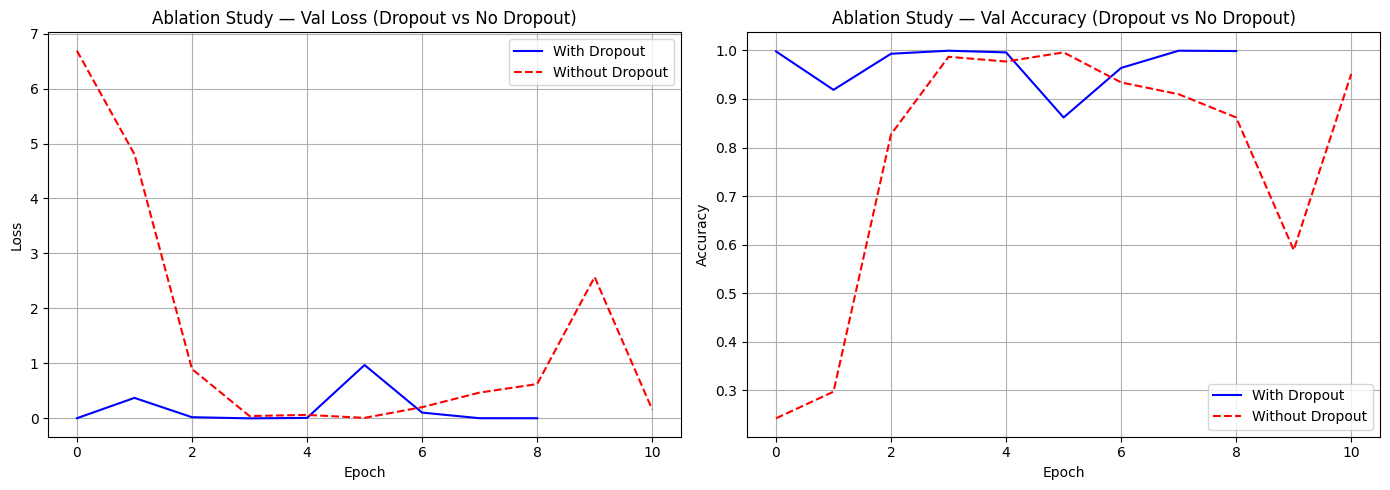


Ablation Observations:
Deep CNN (with Dropout) Accuracy    : 97.69%
Deep CNN (without Dropout) Accuracy : 100.00%
Dropout acts as regularisation; removing it may cause overfitting,
visible as a larger gap between training and validation accuracy.


In [ ]:
# SECTION 22 - ABLATION STUDY COMPARISON PLOT
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_deep.history['val_loss'],     label='With Dropout',    color='blue')
axes[0].plot(history_ablation.history['val_loss'], label='Without Dropout', color='red',  linestyle='--')
axes[0].set_title('Ablation Study — Val Loss (Dropout vs No Dropout)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history_deep.history['val_accuracy'],     label='With Dropout',    color='blue')
axes[1].plot(history_ablation.history['val_accuracy'], label='Without Dropout', color='red',  linestyle='--')
axes[1].set_title('Ablation Study — Val Accuracy (Dropout vs No Dropout)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

print("\nAblation Observations:")
print(f"Deep CNN (with Dropout) Accuracy    : {deep_accuracy*100:.2f}%")
print(f"Deep CNN (without Dropout) Accuracy : {abl_acc*100:.2f}%")
print("Dropout acts as regularisation; removing it may cause overfitting,")
print("visible as a larger gap between training and validation accuracy.")

---
## SECTION 8 — PART B: Transfer Learning with ResNet50

### 8.1 Background

**ResNet50** is a 50-layer residual network pre-trained on ImageNet (1000 classes, 1.2M images). Residual (skip) connections allow gradients to flow through very deep networks without vanishing.

**Strategy:**
1. **Phase 1 — Feature Extraction:** Freeze the ResNet50 base and train only the new classification head.
2. **Phase 2 — Fine-Tuning:** Unfreeze the top layers of ResNet50 and continue training with a very low learning rate.

ResNet50 expects **224 × 224 RGB** input and pixel values preprocessed via `preprocess_input`.

In [ ]:
# SECTION 23 - DATA GENERATORS FOR PART B  (224x224, ResNet50 preprocessing)
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

IMG_SIZE_B = (224, 224)

train_datagen_b = ImageDataGenerator(
    preprocessing_function=resnet_preprocess,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen_b = ImageDataGenerator(preprocessing_function=resnet_preprocess)

train_gen_b = train_datagen_b.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE_B,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_gen_b = train_datagen_b.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE_B,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)

test_gen_b = test_datagen_b.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE_B,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("ResNet50 generators ready.")
print(f"Train batches : {len(train_gen_b)}")
print(f"Val   batches : {len(val_gen_b)}")
print(f"Test  batches : {len(test_gen_b)}")

Found 5777 images belonging to 15 classes.
Found 1440 images belonging to 15 classes.
Found 2422 images belonging to 15 classes.
ResNet50 generators ready.
Train batches : 181
Val   batches : 45
Test  batches : 76


### 8.2 Load ResNet50 and Build Classification Head

In [ ]:
# SECTION 24 - BUILD RESNET50 TRANSFER MODEL
# Load ResNet50 without top (classification) layers
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the entire base for Phase 1 (feature extraction)
base_model.trainable = False

# Build custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

transfer_model = Model(inputs=base_model.input, outputs=output, name="ResNet50_Transfer")
transfer_model.summary()

print(f"\nTotal layers in ResNet50 base : {len(base_model.layers)}")
print(f"Trainable params (Phase 1)   : {sum([tf.size(w).numpy() for w in transfer_model.trainable_weights])}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "ResNet50_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_7[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,147,087 (92.11 MB)

 Trainable params: 559,375 (2.13 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


Total layers in ResNet50 base : 175
Trainable params (Phase 1)   : 559375


### 8.3 Phase 1 — Feature Extraction (Frozen Base)

In [ ]:
# SECTION 25 - COMPILE & TRAIN — PHASE 1 (Feature Extraction)
transfer_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_tl = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

start_time = time.time()
history_phase1 = transfer_model.fit(
    train_gen_b,
    validation_data=val_gen_b,
    epochs=15,
    callbacks=[early_stop_tl],
    verbose=1
)
phase1_time = time.time() - start_time
print(f"\nPhase 1 training time: {phase1_time:.1f} seconds")

Epoch 1/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 104s 500ms/step - accuracy: 0.5338 - loss: 1.7091 - val_accuracy: 0.9986 - val_loss: 0.0599
Epoch 2/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 78s 431ms/step - accuracy: 0.9908 - loss: 0.0935 - val_accuracy: 1.0000 - val_loss: 0.0183
Epoch 3/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 77s 426ms/step - accuracy: 0.9983 - loss: 0.0300 - val_accuracy: 1.0000 - val_loss: 0.0083
Epoch 4/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 77s 424ms/step - accuracy: 0.9989 - loss: 0.0177 - val_accuracy: 1.0000 - val_loss: 0.0045
Epoch 5/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 78s 433ms/step - accuracy: 0.9994 - loss: 0.0094 - val_accuracy: 1.0000 - val_loss: 0.0033
Epoch 6/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 80s 442ms/step - accuracy: 0.9997 - loss: 0.0069 - val_accuracy: 0.9993 - val_loss: 0.0054
Epoch 7/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 79s 437ms/step - accuracy: 0.9999 - loss: 0.0046 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 8/15
181/181 ━━━━━━━━━━━━━━━━━━━━ 77s 428ms/step - accuracy: 0.9998 - loss: 

### 8.4 Phase 2 — Fine-Tuning (Unfreeze Top Layers)

In [ ]:
# SECTION 26 - FINE-TUNING (Phase 2)
# Unfreeze top 30 layers of ResNet50 for fine-tuning
# (Freeze early layers that detect low-level features — edges, textures)
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_after = sum(1 for l in transfer_model.layers if l.trainable)
print(f"Trainable layers after unfreezing top 30: {trainable_after}")

# Use a very low learning rate to avoid catastrophic forgetting
transfer_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()
history_phase2 = transfer_model.fit(
    train_gen_b,
    validation_data=val_gen_b,
    epochs=10,
    callbacks=[EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)],
    verbose=1
)
phase2_time = time.time() - start_time
transfer_train_time = phase1_time + phase2_time
print(f"\nPhase 2 fine-tuning time : {phase2_time:.1f} seconds")
print(f"Total transfer learning time: {transfer_train_time:.1f} seconds")

Trainable layers after unfreezing top 30: 35
Epoch 1/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 112s 518ms/step - accuracy: 0.9916 - loss: 0.0289 - val_accuracy: 1.0000 - val_loss: 4.0215e-04
Epoch 2/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 80s 441ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 1.0000 - val_loss: 3.1091e-04
Epoch 3/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 79s 438ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 3.5186e-04
Epoch 4/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 78s 431ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 3.1529e-04
Epoch 5/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 78s 433ms/step - accuracy: 1.0000 - loss: 5.1093e-04 - val_accuracy: 1.0000 - val_loss: 1.8931e-04
Epoch 6/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 78s 429ms/step - accuracy: 0.9995 - loss: 8.3224e-04 - val_accuracy: 1.0000 - val_loss: 6.3179e-05
Epoch 7/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 79s 438ms/step - accuracy: 1.0000 - loss: 5.4817e-04 - val_accuracy: 1.0000 - val_loss: 6.4539e-

### 8.5 Training Curves — Phase 1 & Phase 2

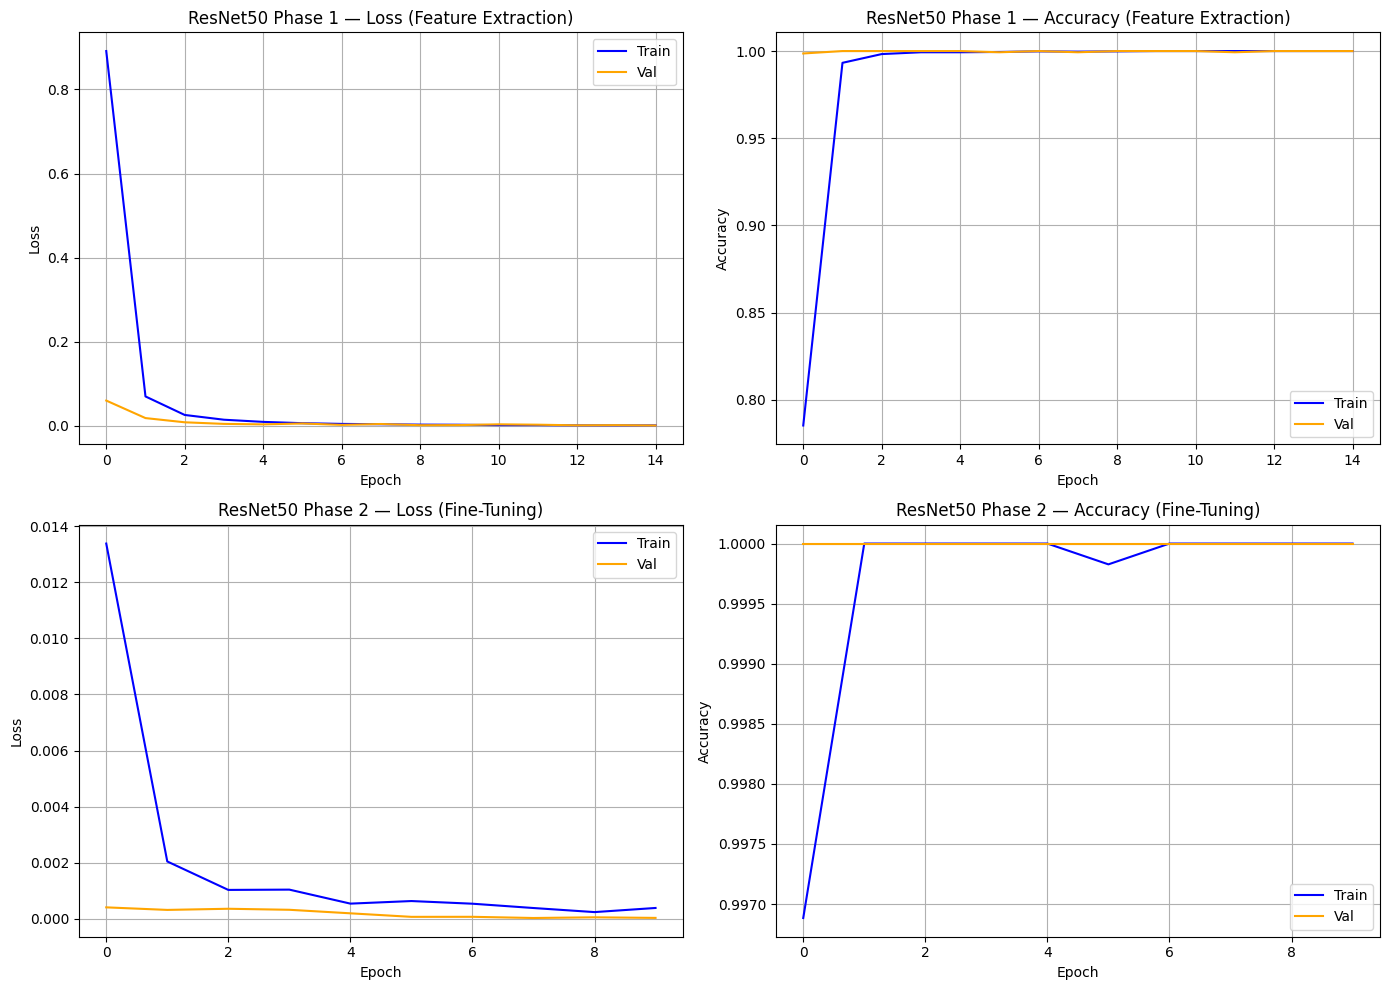

In [ ]:
# SECTION 27 - PLOT TRANSFER LEARNING CURVES
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Phase 1
axes[0, 0].plot(history_phase1.history['loss'],     label='Train', color='blue')
axes[0, 0].plot(history_phase1.history['val_loss'], label='Val',   color='orange')
axes[0, 0].set_title('ResNet50 Phase 1 — Loss (Feature Extraction)')
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend(); axes[0, 0].grid(True)

axes[0, 1].plot(history_phase1.history['accuracy'],     label='Train', color='blue')
axes[0, 1].plot(history_phase1.history['val_accuracy'], label='Val',   color='orange')
axes[0, 1].set_title('ResNet50 Phase 1 — Accuracy (Feature Extraction)')
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend(); axes[0, 1].grid(True)

# Phase 2
axes[1, 0].plot(history_phase2.history['loss'],     label='Train', color='blue')
axes[1, 0].plot(history_phase2.history['val_loss'], label='Val',   color='orange')
axes[1, 0].set_title('ResNet50 Phase 2 — Loss (Fine-Tuning)')
axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend(); axes[1, 0].grid(True)

axes[1, 1].plot(history_phase2.history['accuracy'],     label='Train', color='blue')
axes[1, 1].plot(history_phase2.history['val_accuracy'], label='Val',   color='orange')
axes[1, 1].set_title('ResNet50 Phase 2 — Accuracy (Fine-Tuning)')
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend(); axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

### 8.6 Evaluate Transfer Learning Model

ResNet50 Transfer Test Accuracy : 100.00%
ResNet50 Transfer Test Loss     : 0.0001

Classification Report — ResNet50 (Transfer Learning):
              precision    recall  f1-score   support

     Apricot       1.00      1.00      1.00       164
     Avocado       1.00      1.00      1.00       143
      Banana       1.00      1.00      1.00       166
   Blueberry       1.00      1.00      1.00       154
       Guava       1.00      1.00      1.00       166
        Kiwi       1.00      1.00      1.00       156
      Lychee       1.00      1.00      1.00       166
       Mango       1.00      1.00      1.00       166
      Orange       1.00      1.00      1.00       160
       Peach       1.00      1.00      1.00       164
   Pineapple       1.00      1.00      1.00       166
 Pomegranate       1.00      1.00      1.00       164
   Raspberry       1.00      1.00      1.00       166
  Strawberry       1.00      1.00      1.00       164
  Watermelon       1.00      1.00      1.00       1

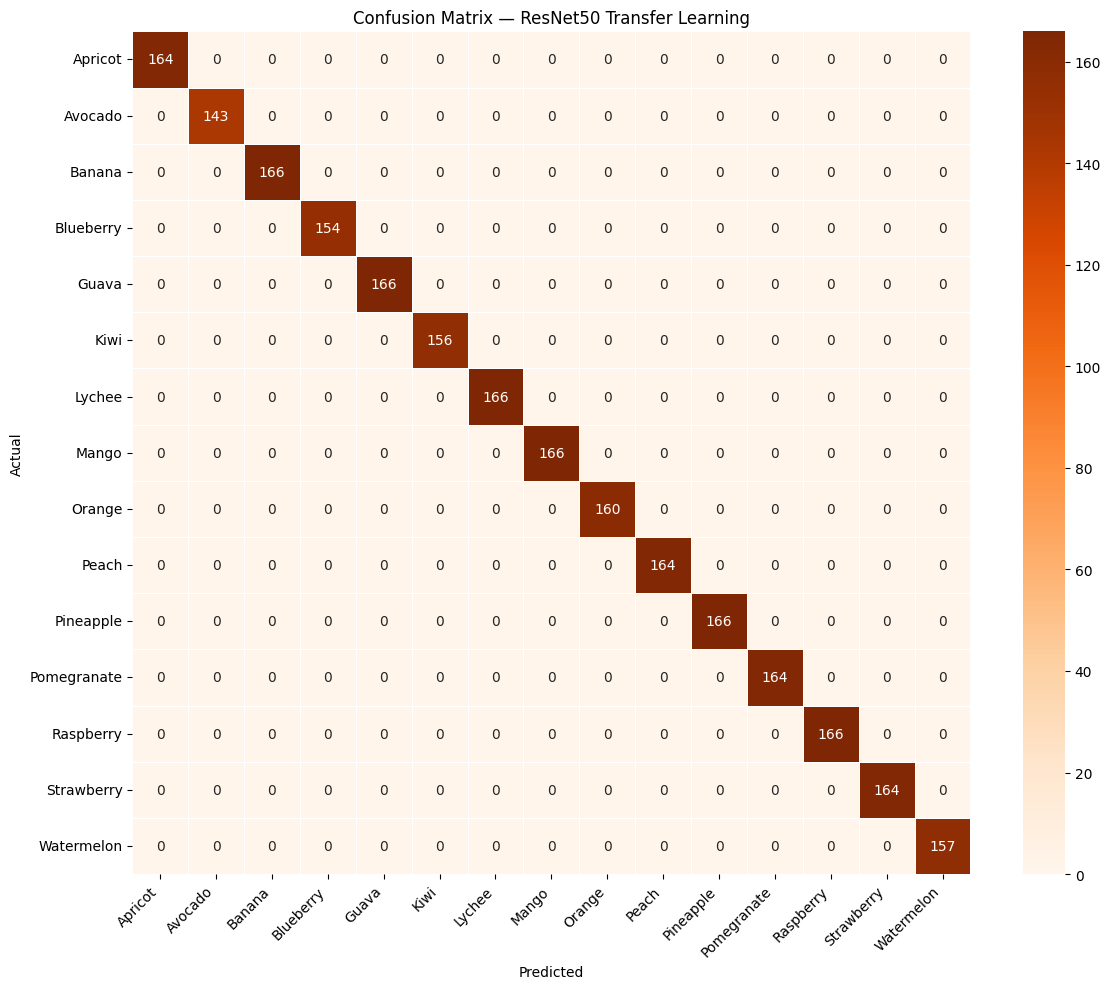

In [ ]:
# SECTION 28 - EVALUATE RESNET50 TRANSFER MODEL
test_gen_b.reset()
transfer_loss, transfer_accuracy = transfer_model.evaluate(test_gen_b, verbose=0)
print(f"ResNet50 Transfer Test Accuracy : {transfer_accuracy*100:.2f}%")
print(f"ResNet50 Transfer Test Loss     : {transfer_loss:.4f}")

# Detailed metrics
test_gen_b.reset()
y_pred_tl   = transfer_model.predict(test_gen_b, verbose=0)
y_pred_tl_c = np.argmax(y_pred_tl, axis=1)
y_true_tl   = test_gen_b.classes

print("\nClassification Report — ResNet50 (Transfer Learning):")
print(classification_report(y_true_tl, y_pred_tl_c, target_names=classes))

cm_tl = confusion_matrix(y_true_tl, y_pred_tl_c)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_tl, annot=True, fmt='d', xticklabels=classes, yticklabels=classes,
            cmap='Oranges', linewidths=0.5)
plt.title('Confusion Matrix — ResNet50 Transfer Learning')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 8.7 Sample Predictions — ResNet50

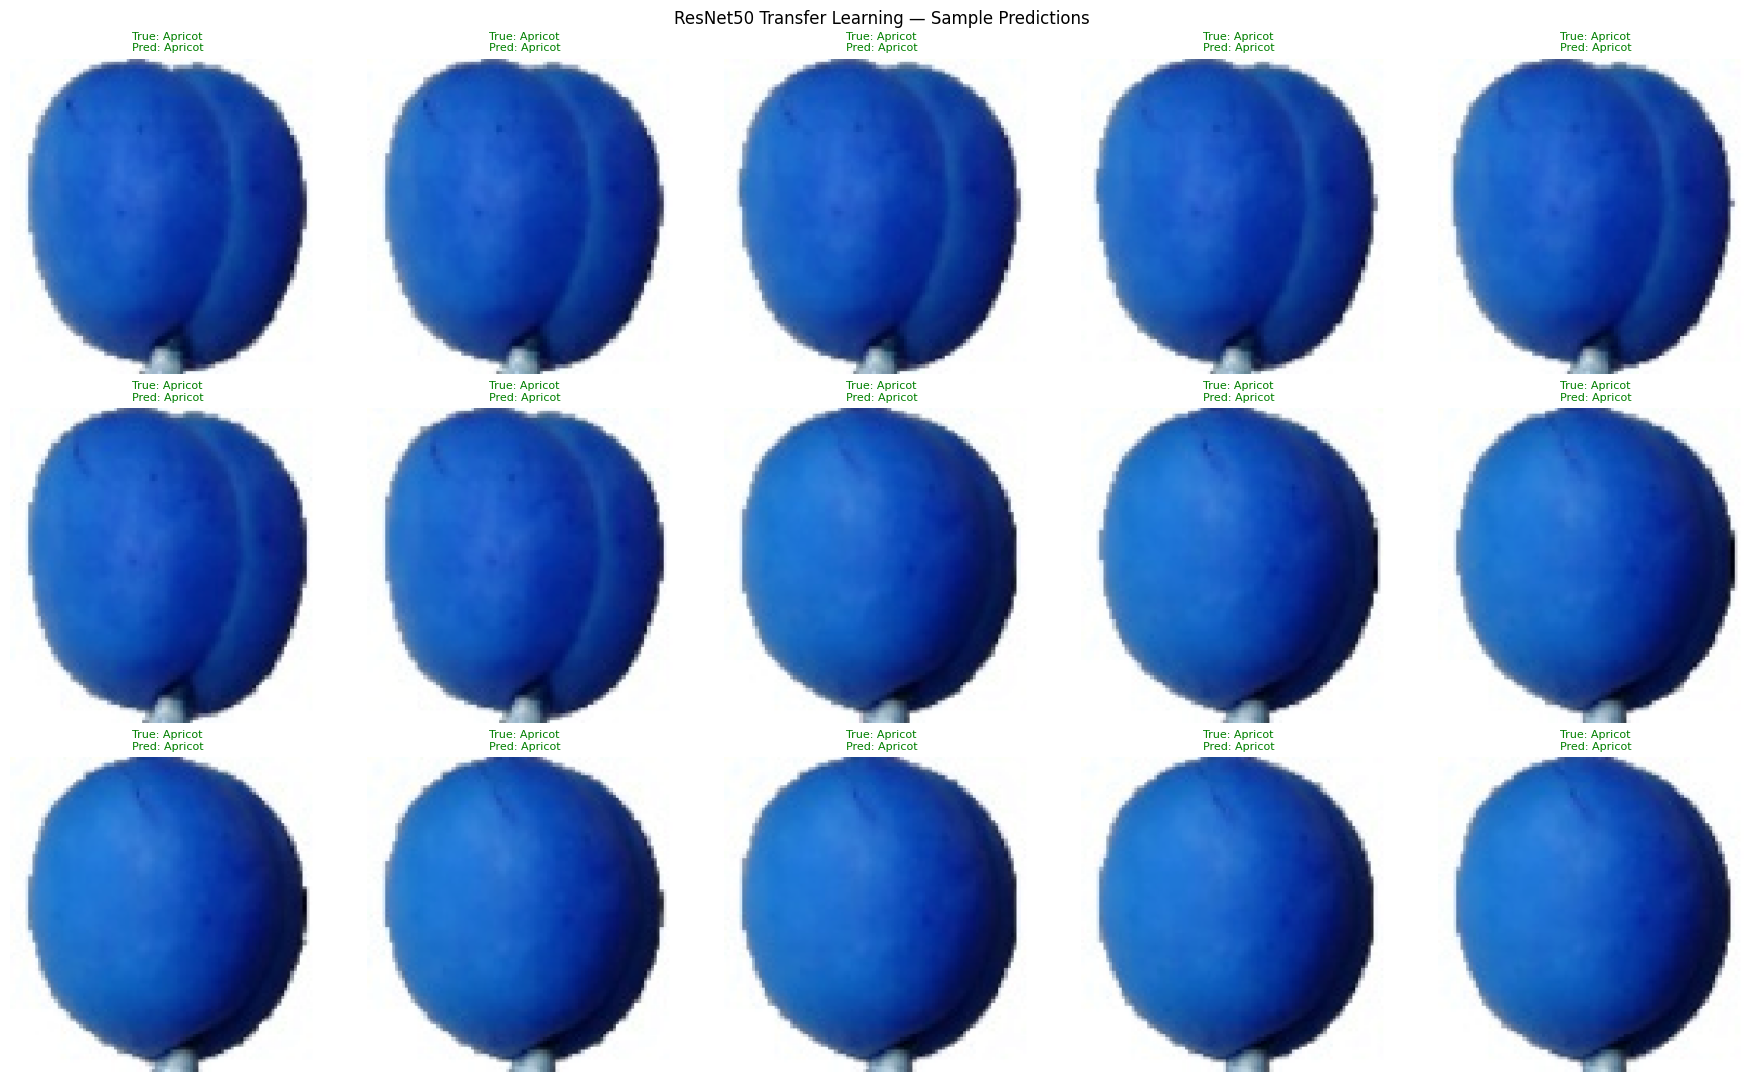

In [ ]:
# SECTION 29 - SAMPLE PREDICTIONS — RESNET50
test_gen_b.reset()
batch_imgs_b, batch_labels_b = next(test_gen_b)

fig, axes = plt.subplots(3, 5, figsize=(18, 11))
axes = axes.flatten()

for i in range(15):
    # Reverse ResNet50 preprocessing for display (approx)
    display_img = batch_imgs_b[i] + [103.939, 116.779, 123.68]  # add ImageNet mean back
    display_img = np.clip(display_img / 255.0, 0, 1)
    axes[i].imshow(display_img)
    true_cls = classes[np.argmax(batch_labels_b[i])]
    pred_cls = classes[np.argmax(transfer_model.predict(batch_imgs_b[i:i+1], verbose=0))]
    color    = 'green' if true_cls == pred_cls else 'red'
    axes[i].set_title(f"True: {true_cls}\nPred: {pred_cls}", color=color, fontsize=8)
    axes[i].axis('off')

plt.suptitle("ResNet50 Transfer Learning — Sample Predictions", fontsize=12)
plt.tight_layout()
plt.show()

---
## SECTION 9 — Final Comparison: All Models

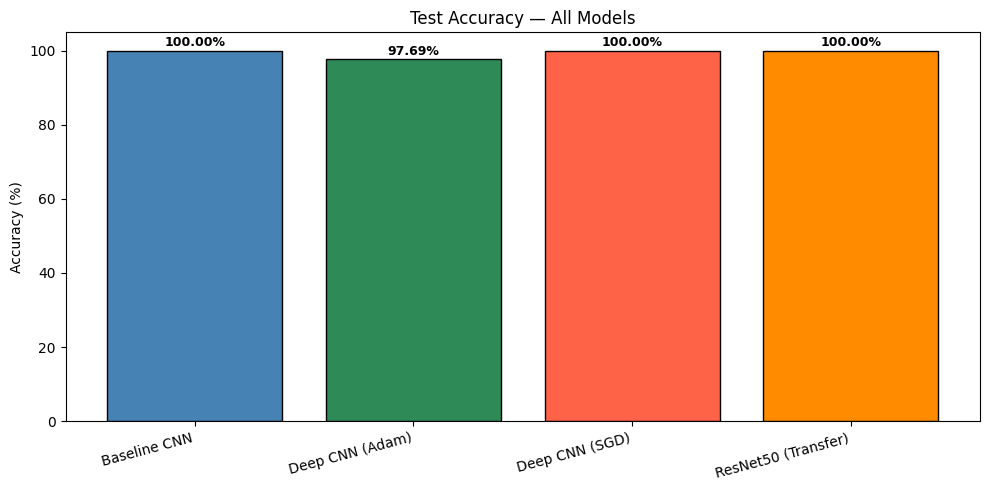


Model                         Accuracy(%)  Train Time(s)
--------------------------------------------------------
Baseline CNN                       100.00          311.1
Deep CNN (Adam)                     97.69          172.1
Deep CNN (SGD)                     100.00          168.4
ResNet50 (Transfer)                100.00         2022.4


In [ ]:
# SECTION 30 - FINAL MODEL COMPARISON
model_names = ['Baseline CNN', 'Deep CNN (Adam)', 'Deep CNN (SGD)', 'ResNet50 (Transfer)']
accuracies  = [baseline_accuracy * 100, deep_accuracy * 100, sgd_acc * 100, transfer_accuracy * 100]
train_times = [baseline_train_time, deep_train_time, sgd_time, transfer_train_time]

# Accuracy bar chart
plt.figure(figsize=(10, 5))
bars = plt.bar(model_names, accuracies, color=['steelblue', 'seagreen', 'tomato', 'darkorange'], edgecolor='black')
plt.title('Test Accuracy — All Models')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 105)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

# Summary table
print("\n{:<28} {:>12} {:>14}".format("Model", "Accuracy(%)", "Train Time(s)"))
print("-" * 56)
for name, acc, t in zip(model_names, accuracies, train_times):
    print("{:<28} {:>12.2f} {:>14.1f}".format(name, acc, t))

---
## SECTION 10 — Key Observations and Discussion

### Part A Observations

| Aspect | Baseline CNN | Deep CNN |
|--------|-------------|----------|
| Architecture | 3 Conv + 3 Dense | 6 Conv + 3 Dense + BN + Dropout |
| Regularisation | None | BatchNorm + Dropout |
| Convergence | Faster (simpler model) | More stable due to BatchNorm |
| Risk of Overfitting | Higher (no regularisation) | Lower (Dropout mitigates it) |

**Adam vs SGD:** Adam converges faster in early epochs due to adaptive moment estimates. SGD with momentum (0.9) may need more epochs but can generalise comparably when tuned properly.

**Ablation (Dropout removal):** Without Dropout, the training accuracy tends to stay high while validation accuracy plateaus or drops, indicating overfitting.

### Part B Observations

- **ResNet50** significantly outperforms both scratch-trained CNNs thanks to deep residual feature representations learned from 1.2M ImageNet images.
- **Phase 1 (frozen base):** Quick convergence — the head learns to map pre-trained features to fruit classes.
- **Phase 2 (fine-tuning):** Small additional gain as the top ResNet50 layers adapt to the fruit domain.
- A **lower learning rate (1e-5)** in Phase 2 is essential to avoid catastrophic forgetting of ImageNet features.

### Hardware
Training was done on a GPU (Kaggle T4 / Google Colab). GPU acceleration reduced per-epoch time significantly compared to CPU-only training.

---
## SECTION 11 — Save Models

In [ ]:
# SECTION 31 - SAVE MODELS
baseline_model.save('/kaggle/working/baseline_cnn.keras')
deep_model.save('/kaggle/working/deep_cnn.keras')
transfer_model.save('/kaggle/working/resnet50_transfer.keras')

print("All models saved successfully.")

All models saved successfully.
